In [12]:
import pandas as pd
# From CSV file
df = pd.read_csv('/content/drive/MyDrive/owid-energy-data.csv')
print("Dataset shape:", df.shape)
print("First 5 rows:")
print(df.head())


Dataset shape: (23195, 130)
First 5 rows:
         country  year iso_code  population  gdp  biofuel_cons_change_pct  \
0  ASEAN (Ember)  2000      NaN         NaN  NaN                      NaN   
1  ASEAN (Ember)  2001      NaN         NaN  NaN                      NaN   
2  ASEAN (Ember)  2002      NaN         NaN  NaN                      NaN   
3  ASEAN (Ember)  2003      NaN         NaN  NaN                      NaN   
4  ASEAN (Ember)  2004      NaN         NaN  NaN                      NaN   

   biofuel_cons_change_twh  biofuel_cons_per_capita  biofuel_consumption  \
0                      NaN                      NaN                  NaN   
1                      NaN                      NaN                  NaN   
2                      NaN                      NaN                  NaN   
3                      NaN                      NaN                  NaN   
4                      NaN                      NaN                  NaN   

   biofuel_elec_per_capita  ...  solar

In [13]:
target_col = 'primary_energy_consumption'


In [14]:
# Drop cols with > 50% missing values
threshold = len(df) * 0.5
df = df.dropna(axis=1, thresh=threshold)


In [15]:
df.columns.tolist()

['country',
 'year',
 'iso_code',
 'population',
 'gdp',
 'coal_prod_change_twh',
 'coal_prod_per_capita',
 'coal_production',
 'energy_cons_change_pct',
 'energy_cons_change_twh',
 'gas_prod_change_twh',
 'gas_prod_per_capita',
 'gas_production',
 'oil_prod_change_twh',
 'oil_prod_per_capita',
 'oil_production',
 'primary_energy_consumption']

In [16]:
df

,country,year,iso_code,population,gdp,coal_prod_change_twh,coal_prod_per_capita,coal_production,energy_cons_change_pct,energy_cons_change_twh,gas_prod_change_twh,gas_prod_per_capita,gas_production,oil_prod_change_twh,oil_prod_per_capita,oil_production,primary_energy_consumption
0,ASEAN (Ember),2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ASEAN (Ember),2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ASEAN (Ember),2002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ASEAN (Ember),2003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ASEAN (Ember),2004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23190,Zimbabwe,2020,ZWE,15526887.0,2.317871e+10,0.592,1306.886,20.292,-15.539,-6.179,NaN,NaN,NaN,NaN,NaN,NaN,33.586
23191,Zimbabwe,2021,ZWE,15797220.0,2.514009e+10,3.999,1537.673,24.291,12.059,4.050,NaN,NaN,NaN,NaN,NaN,NaN,37.636
23192,Zimbabwe,2022,ZWE,16069061.0,2.590159e+10,5.263,1839.164,29.554,55.118,20.744,NaN,NaN,NaN,NaN,NaN,NaN,58.380
23193,Zimbabwe,2023,ZWE,16340829.0,NaN,7.859,2289.525,37.413,-10.952,-6.394,NaN,NaN,NaN,NaN,NaN,NaN,51.986


In [17]:
X = df.drop(columns=[target_col])
y = df[target_col]

# Keep only numeric columns
X = X.select_dtypes(include='number')

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score

In [22]:
models = {
    "Adam": MLPRegressor(solver='adam', hidden_layer_sizes=(64,32), max_iter=500, random_state=42),
    "SGD": MLPRegressor(solver='sgd', hidden_layer_sizes=(64,32), max_iter=500, learning_rate_init=0.01, random_state=42),
    "LBFGS": MLPRegressor(solver='lbfgs', hidden_layer_sizes=(64,32), max_iter=500, random_state=42)
}

In [25]:
print(y_train.isna().sum())


7973


In [26]:
# Keep only rows where y is not null
not_null_idx = y_train.notna()

X_train_scaled = X_train_scaled[not_null_idx]
y_train = y_train[not_null_idx]


In [27]:
# Assuming X_train_scaled and y_train are ready

from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(
    hidden_layer_sizes=(64, 32),  # Two hidden layers: 64 and 32 neurons
    activation='relu',            # Recommended for regression
    solver='adam',                # Optimization algorithm
    max_iter=500,
    random_state=42
)

# Train the model on scaled training data
mlp.fit(X_train_scaled, y_train)

# Check training results
print(f"Training completed in {mlp.n_iter_} iterations")
print(f"Final loss: {mlp.loss_:.4f}")


Training completed in 500 iterations
Final loss: 15430506.8769


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

# Load dataset
dataset = pd.read_csv('/content/drive/MyDrive/bank-additional-full (1).csv')

# Display first few rows
print(dataset.head())

# Display column names
print(dataset.columns)

# Dataset shape
print("Dataset Shape:", dataset.shape)


   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

In [34]:
# Define target column
target_col = 'y'

# Features (all columns except target)
X = dataset.drop(columns=[target_col])

# Target
y = dataset[target_col]

print("Feature Data Shape:", X.shape)
print("Target Shape:", y.shape)


Feature Data Shape: (41188, 20)
Target Shape: (41188,)


In [35]:
print(y.value_counts())


y
no     36548
yes     4640
Name: count, dtype: int64


In [36]:
print(dataset.isnull().sum())


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [38]:
# Categorical columns
categorical_cols = X.select_dtypes(include=['object', 'category']).columns
print("Categorical Columns:", categorical_cols)

# Numeric columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
print("Numeric Columns:", numeric_cols)


Categorical Columns: Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')
Numeric Columns: Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')


In [41]:
dataset[categorical_cols].nunique()


,0
job,12
marital,4
education,8
default,3
housing,3
loan,3
contact,2
month,10
day_of_week,5
poutcome,3


In [42]:
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print("Encoded Feature Shape:", X_encoded.shape)


Encoded Feature Shape: (41188, 53)


In [45]:
X_encoded = X_encoded.astype(int)
X_encoded


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,261,1,999,0,1,93,-36,4,5191,...,1,0,0,0,1,0,0,0,1,0
1,57,149,1,999,0,1,93,-36,4,5191,...,1,0,0,0,1,0,0,0,1,0
2,37,226,1,999,0,1,93,-36,4,5191,...,1,0,0,0,1,0,0,0,1,0
3,40,151,1,999,0,1,93,-36,4,5191,...,1,0,0,0,1,0,0,0,1,0
4,56,307,1,999,0,1,93,-36,4,5191,...,1,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,334,1,999,0,-1,94,-50,1,4963,...,0,1,0,0,0,0,0,0,1,0
41184,46,383,1,999,0,-1,94,-50,1,4963,...,0,1,0,0,0,0,0,0,1,0
41185,56,189,2,999,0,-1,94,-50,1,4963,...,0,1,0,0,0,0,0,0,1,0
41186,44,442,1,999,0,-1,94,-50,1,4963,...,0,1,0,0,0,0,0,0,1,0


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)
print("Scaler mean:", scaler.mean_)
print("Scaler scale:", scaler.scale_)


Training set shape: (32950, 53)
Testing set shape: (8238, 53)
Scaler mean: [ 4.00174203e+01  2.57746313e+02  2.57295903e+00  9.62745341e+02
  1.72989378e-01  1.54628225e-01  9.29243703e+01 -4.01280425e+01
  2.92367223e+00  5.16690662e+03  2.25766313e-01  3.47496206e-02
  2.63125948e-02  7.01062215e-02  4.13657056e-02  3.49924127e-02
  9.74810319e-02  2.18816388e-02  1.62427921e-01  2.42185129e-02
  7.95144158e-03  6.01608498e-01  2.83247344e-01  1.85128983e-03
  5.62063733e-02  1.45918058e-01  2.31077390e-01  3.94537178e-04
  1.26737481e-01  2.95902883e-01  4.24582701e-02  2.08103187e-01
  9.10470410e-05  2.46130501e-02  5.23732929e-01  2.46130501e-02
  1.51866464e-01  3.64764795e-01  1.49742033e-01  4.30955994e-03
  1.75265554e-01  1.30075873e-01  1.35356601e-02  3.31866464e-01
  1.00576631e-01  1.74203338e-02  1.38998483e-02  2.06160850e-01
  2.08558422e-01  1.97663126e-01  1.97359636e-01  8.63034901e-01
  3.30804249e-02]
Scaler scale: [1.04356835e+01 2.59455926e+02 2.77809613e+00 1.

In [47]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
    hidden_layer_sizes=(50, 25),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

print("Model architecture:", mlp.hidden_layer_sizes)
print("Activation function:", mlp.activation)
print("Solver:", mlp.solver)
print("Maximum iterations:", mlp.max_iter)


Model architecture: (50, 25)
Activation function: relu
Solver: adam
Maximum iterations: 500


In [48]:
# Train model
mlp.fit(X_train_scaled, y_train)

print(f"Training completed in {mlp.n_iter_} iterations")
print(f"Final training loss: {mlp.loss_:.4f}")
print(f"Training set accuracy: {mlp.score(X_train_scaled, y_train):.4f}")

# Convergence check
if mlp.n_iter_ == mlp.max_iter:
    print("Warning: Model may not have converged.")
else:
    print("Model converged successfully.")


Training completed in 410 iterations
Final training loss: 0.0618
Training set accuracy: 0.9785
Model converged successfully.


In [49]:
from sklearn.metrics import accuracy_score

y_pred = mlp.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Number of test samples: {len(y_test)}")
print(f"Number of correct predictions: {sum(y_pred == y_test)}")


Test Accuracy: 0.8878 (88.78%)
Number of test samples: 8238
Number of correct predictions: 7314


Classification Report:
              precision    recall  f1-score   support

          no       0.94      0.94      0.94      7303
         yes       0.51      0.50      0.51       935

    accuracy                           0.89      8238
   macro avg       0.72      0.72      0.72      8238
weighted avg       0.89      0.89      0.89      8238



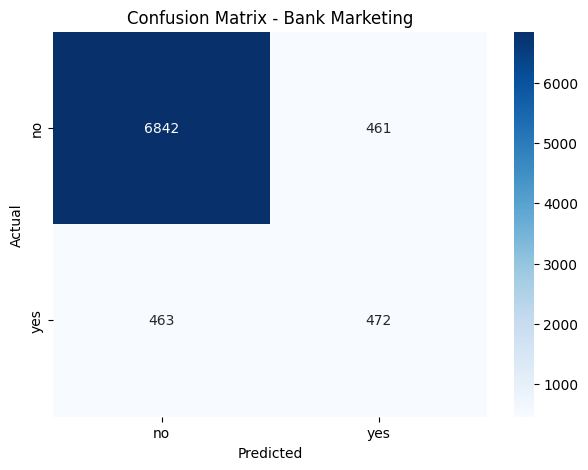

In [50]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=mlp.classes_,
    yticklabels=mlp.classes_
)
plt.title("Confusion Matrix - Bank Marketing")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred, pos_label='yes')
recall = recall_score(y_test, y_pred, pos_label='yes')
f1 = f1_score(y_test, y_pred, pos_label='yes')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
